# Run a photochemical simulation with IsoChem

In this tutorial, we provide an example of how to run a simulation with IsoChem. We will go through the different steps one needs to follow to generate the necessary inputs, run the model, and read the outputs. 

In [1]:
import isochem
import matplotlib.pyplot as plt
import numpy as np
import shutil, os, sys
import h5py

## 1. Input files

### 1.1. Reference atmosphere

In order to run a simulation, we need to have information about the vertical profiles of different atmospheric species. This is especially true for the major species in the atmosphere, which will be the sources of radicals of other minor species. For the Martian atmosphere, these species would be for instance CO$_2$, H$_2$O or N$_2$, and are therefore key inputs to run the simulation. Similarly, we need information about the atmospheric temperature.

These profiles are included in the input HDF5 atmospheric file. This file will represent the starting point of our simulation (i.e., the density of different atmospheric species at t=0). As mentioned, the most important profiles are those of the major species in the atmosphere. For the minor species, while the simulation will converge faster if we use some profiles that are closer to the true solution, we may as well assume very small abundances, and their densities will be found out at the end of the simulation.

In this example, we have generated this file using information from the Mars Climate Database (MCD) at Latitude = 0$^\circ$N, Longitude = 0$^\circ$N, $L_{\mathrm{S}}$ = 90$^\circ$ and LST = 12 h. The MCD includes information for many species, but not all. For the species we had no information, we have used a volume mixing ratio of $10^{-30}$.

In IsoChem, each gas (or isotope) is identified by a gasID and an isoID, largely based on the definition by HITRAN. The information about the IDs for different gases is stored in the source code, under isochem/dict/gas_dict.py. Generally, isoID = 0 indicates the major isotope, while higher numbers indicate minor isotopes. For instance:
- gasID = 1, isoID = 0: H$_2$O
- gasID = 1, isoID = 2: H$_2^{18}$O
- gasID = 1, isoID = 4: HDO
- gasID = 2, isoID = 0: CO$_2$

One can include new gases by adding a new ID and information about the gas to the dictionary.

In [2]:
#Name of input atmospheric file (i.e. atmosphere at t=0)
atm_file = 'mars_mcd_aphelion_ini'

#We can read this file using 
h,T,gasID,isoID,N,time = isochem.utils.read_hdf5(atm_file)

#Calculating the total density - the shape of the N array is (nh,ngas,ntime)
Ntot0 = np.sum(N[:,:,0],axis=1)

#Calculating the pressure
k_B = 1.380649e-23   #Boltzmann constant
P0 = Ntot0 * k_B * T

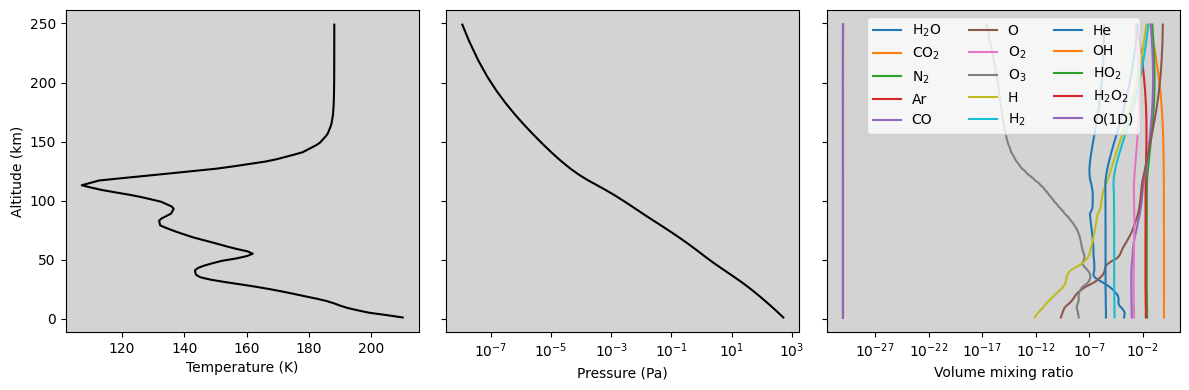

In [3]:
#Exploring the inputs
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(12,4),sharey=True)

#Plotting the temperature
ax1.plot(T,h/1.0e3,c="black")
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Altitude (km)")
ax1.set_facecolor("lightgray")

#Plotting the pressure
ax2.plot(P0,h/1.0e3,c="black")
ax2.set_xscale("log")
ax2.set_xlabel("Pressure (Pa)")
ax2.set_facecolor("lightgray")

#Plotting the volume mixing ratio of each gas
itime = 0
for igas in range(len(gasID)):

    #Getting the name of the gas based on the IDs
    label = isochem.id_to_label(gasID[igas],isoID[igas])

    ax3.plot(N[:,igas,itime]/Ntot0,h/1.0e3,label=label)

ax3.legend(ncol=3)
ax3.set_xscale("log")
ax3.set_xlabel("Volume mixing ratio")
ax3.set_facecolor("lightgray")
 

plt.tight_layout()

### 1.2. Cross sections file

Similarly, we need to include information about the species that can be photolysed by UV photons. This information is included in another input HDF5 file that has to be generated before running the photochemical simulation. This file includes the information about the photolysis cross sections (at different temperatures) and the branching ratios of the reactions. Here, we used a photolysis file using the scheme from the Mars Planetary Climate Model (PCM). 

We can explore the file in order to see which species are listed and which reactions it involves. One thing to note is that if a species is included in the file but is not present in the atmosphere, then the reactions won't be include when running the simulation. Similarly, if the photolysis of a given species produces another one that is not include in the atmosphere, the reaction won't be included in the photochemistry scheme. In this example, this is the case of the photolysis of N$_2$, which is included in the atmosphere, but not its photolysis products (i.e., N).

In [5]:
#Defining the name of the photolysis file
xs_file = 'LMD_xs'

#Reading the photolysis file
wl,wc,wu,temp,ngas,sID_xs,sISO_xs,xs,nreactions,sID,sISO,npr,pID,pISO,pf,branching_ratios = isochem.photolysis.read_xs_combined_hdf5(xs_file)

#Printing all the photolysis reactions included in the file
for i in range(nreactions):
    str_reaction = isochem.photolysis.print_photolysis_reaction(sID[i],sISO[i],npr[i],pID[0:npr[i],i],pISO[0:npr[i],i],pf[0:npr[i],i])
    print(str_reaction)

CO2 + hv ---> CO + O
CO2 + hv ---> CO + O(1D)
N2 + hv ---> 2*N
N2 + hv ---> N2+ + e-
H2O + hv ---> OH + H
NO + hv ---> N + O
NO + hv ---> NO+ + e-
HO2 + hv ---> OH + O
O3 + hv ---> O2 + O
O3 + hv ---> O2 + O(1D)
H2 + hv ---> 2*H
H2O2 + hv ---> 2*OH
O2 + hv ---> 2*O
O2 + hv ---> O + O(1D)
NO2 + hv ---> NO + O


### 1.3. Solar flux

Similarly, we need information about the solar spectrum. Since here we are simulating the Martian atmosphere, we need a solar spectrum from the Sun, but if we were to simulate exoplanet atmospheres, we would need a different solar spectrum.

This is stored in an input HDF5 file, which includes the wavelength of the spectrum, as well as the stellar flux at 1 AU.

In [6]:
#Defining the name of the solar file
sol_file = "atlas3_thuillier_tuv"

#Reading the solar file
wave,solflux = isochem.photolysis.read_solflux_hdf5(sol_file)

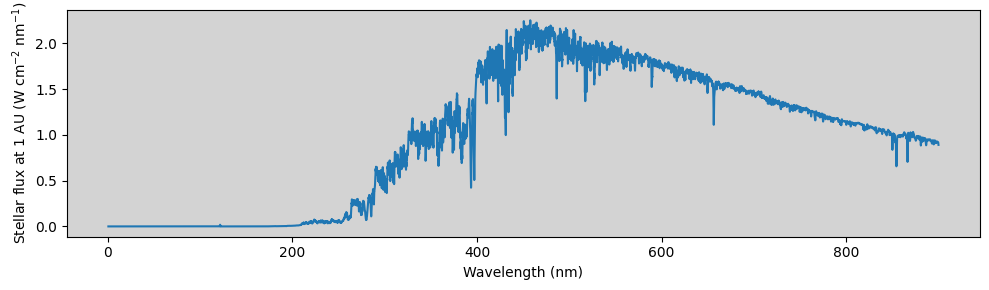

In [7]:
fig,ax1 = plt.subplots(1,1,figsize=(10,3))
ax1.plot(wave,solflux)
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Stellar flux at 1 AU (W cm$^{-2}$ nm$^{-1}$)")
ax1.set_facecolor("lightgray")
plt.tight_layout()

## 2. Setting up the simulation

### 2.1. Processing the inputs

In order to not set up the photolysis scheme for every time step of the simulation, we set up everything beforehand. This includes interpolating the photolysis cross sections to the specific temperature at each layer, as well as binning the solar spectrum to the same resolution at which the cross sections are defined.

Similarly, we need to define some other inputs that are relevant for simulating the photochemistry of a specific planet. This information is included in a dictionary in isochem/dict/planet_dict.py. Here, we select it just by choosing the planet's name.

In [8]:
#Reading the inputs
gasID, isoID, hlay, Play, Tlay, Nlay,\
wl,wu,wc,sID_xs,sISO_xs,xs,sID_phot,sISO_phot,npr_phot,pID_phot,pISO_phot,pf_phot,xsr,solflux,\
mmol,A,s,B,\
typelbc,valuelbc,typeubc,valueubc = isochem.converge.initialise_run(atm_file,xs_file,sol_file,planet='Mars')

Similarly, we need to define whether we want to fix any species in the simulation. For Mars, this is particularly relevant in the context of water vapour. Water in the atmosphere of Mars is mainly sourced from the north polar cap. Otherwise, the photochemistry of the atmosphere tends to remove water - if we did not fix it, the water would be removed by some time. Therefore, in order to make sure we have a steady-state of water, we fix the profile from the surface up to 70 km.

In [9]:
#Fixing the H2O profile from 0 to 50 km
gasID_fix = np.array([1])   #H2O
isoID_fix = np.array([0])   #H2O

hmin_fix = np.array([0.])   #Altitude boundaries at which to fix the profile
hmax_fix = np.array([70.0]) 

nlay = len(hlay)
ngas = len(gasID)
fix_species = np.zeros((nlay,ngas),dtype='int32')
for igasx in range(len(gasID_fix)):

    il = np.where( (hlay>=hmin_fix[igasx]*1000.) & (hlay<=hmax_fix[igasx]*1000.) )
    il = il[0]

    ifix = 0
    for igas in range(ngas):
        if ( (gasID_fix[igasx]==gasID[igas]) & (isoID_fix[igasx]==isoID[igas]) ):

            fix_species[il,igas] = 1
            ifix = 1
        
    if ifix==0:
        sys.exit('error :: The gas species to be fixed cannot be found in gas list')

## 2.2. Defining the chemical network

We need to indicate which reactions we are willing to include in the simulation. Each reaction is identified by a reaction ID. All the possible reactions are listed in isochem/reactions.py. We indicate this list just by creating an array with all the IDs of the reactions we want to include.

In order to extend the network to other planets, we would need to extend the database of reactions. In order to do so, one would need to create new functions by using the same format of the existing reactions in isochem/reactions.py. Then, one would also need to include the reaction in the reaction_rate_coefficients() function of the isochem/chemistry.py module.

In [10]:
#Defining the reactions to include in the chemical network (apart from photolysis)
reaction_ids = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 40, 42, 45])

## 3. Running the simulation

Now that we have set up the simulation, we can proceed at running it. Generally, we want to run with increasingly large timesteps, so that we can resolve the chemistry at different timescales. In this example, we are first going to run 1000 at timesteps going from 10$^{-3}$ to 10$^3$ seconds. After, we would run the model with a given timestep until we reach a pre-defined simulation time (e.g., 5 years), but here we will not do so to keep the simulation faster. Note this can take a while to run in any case, depending on the computer specifications, etc.

Alternatively, if we do not want to run the simulation in this jupyter notebook and prefer to do so from the terminal, we can use the run_model_mars.py program included in the same directory. In that simulation, we perform the same steps as here, but then the simulation is run with a timestep of 2500 seconds until we reach a simulation time of 10 years. For reference, it took about 5 hours to run that simulation.

In [10]:
#First of all, we are going to save the initial file so that it is not overwritten
#Copying the atmospheric file so that it is not overwritten
new_atm_file = 'mars_mcd_aphelion_tutorial'
shutil.copyfile(atm_file+'.h5',
                new_atm_file+'.h5')

'mars_mcd_aphelion_tutorial.h5'

In [11]:
#Defining the time steps
niter_per_timestep = 1000
dt_steps = np.logspace(-3,3,7)  #in seconds
nsteps = len(dt_steps)

#Defining arrays to hold current profiles
Pcurr = np.zeros(nlay)
Pcurr[:] = Play[:]
Ncurr = np.zeros((nlay,ngas))
Ncurr[:,:] = Nlay[:,:]

timex = 0.0
for step in range(nsteps):

    dt = dt_steps[step]

    print('Running time step {0}/{1} with dt={2:.2e} seconds for {3} iterations'.format(step+1,nsteps,dt,niter_per_timestep))

    Nnew, tnew = isochem.converge.run_model_implicit(gasID, isoID, hlay, Pcurr, Tlay, Ncurr,                            #Atmospheric profiles
                        reaction_ids,                                                                                   #Chemical network
                        wl,wu,wc,sID_xs,sISO_xs,xs,sID_phot,sISO_phot,npr_phot,pID_phot,pISO_phot,pf_phot,xsr,solflux,  #Photolysis
                        mmol,A,s,B,                                                                                     #Diffusion
                        typelbc,valuelbc,typeubc,valueubc,                                                              #Boundary conditions
                        dt,                                                                                             #Timestep parameters
                        fix_species=fix_species, 
                        planet='Mars',
                        max_iter=niter_per_timestep,
                        time=timex,
                        include_chemistry=True,
                        include_diffusion=True,
                        include_13c=False)
    
    #Updating current profiles
    if np.where(np.isnan(Nnew))[0].size > 0:
        raise ValueError('error :: NaN values encountered during the model run')

    Ncurr[:,:] = Nnew[:,:]
    Pcurr = np.sum(Nnew,axis=1)*isochem.dict.const_dict.phys_const["k_B"]*Tlay
    timex = tnew
    
    #Writing output files
    hf = h5py.File(new_atm_file+'.h5','r+')
    hf['N'].resize((hf['N'].shape[2] + 1), axis=2)
    hf['N'][:,:,hf['N'].shape[2]-1] = Nnew[:,:]
    hf['time'].resize((hf['time'].shape[1] + 1), axis=1)
    hf['time'][:,hf['time'].shape[1] - 1] = np.array([timex])[:,np.newaxis]
    hf.close()

Running time step 1/7 with dt=1.00e-03 seconds for 1000 iterations
Running time step 2/7 with dt=1.00e-02 seconds for 1000 iterations
Running time step 3/7 with dt=1.00e-01 seconds for 1000 iterations
Running time step 4/7 with dt=1.00e+00 seconds for 1000 iterations
Running time step 5/7 with dt=1.00e+01 seconds for 1000 iterations
Running time step 6/7 with dt=1.00e+02 seconds for 1000 iterations
Running time step 7/7 with dt=1.00e+03 seconds for 1000 iterations


## 4. Reading the simulation results

After the simulation has been run, we can read the simulated atmospheric profiles at each timestep. The file where these outputs are stored is the same as the input atmospheric file (that is why we copied it not to overwrite it).

In [12]:
#We can read this file using 
h,T,gasID,isoID,N,time = isochem.utils.read_hdf5(new_atm_file)

#Calculating the total density - the shape of the N array is (nh,ngas,ntime)
Ntot = np.sum(N[:,:,:],axis=1)  #(nh,ntime)

#Calculating the pressure
k_B = 1.380649e-23   #Boltzmann constant
P = (Ntot.T * k_B * T).T   #(nh,ntime)

Simulation time =  1111111.0 seconds


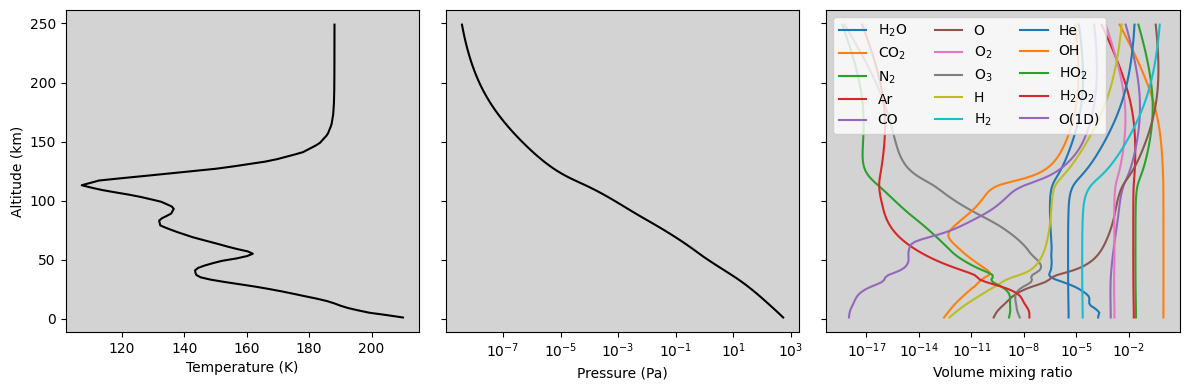

In [14]:
#Exploring the outputs
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(12,4),sharey=True)

itime = -1   #Last timestep
print("Simulation time = ",time[itime],"seconds")

#Plotting the temperature
ax1.plot(T,h/1.0e3,c="black")
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Altitude (km)")
ax1.set_facecolor("lightgray")

#Plotting the pressure
ax2.plot(P[:,itime],h/1.0e3,c="black")
ax2.set_xscale("log")
ax2.set_xlabel("Pressure (Pa)")
ax2.set_facecolor("lightgray")

#Plotting the volume mixing ratio of each gas
for igas in range(len(gasID)):

    #Getting the name of the gas based on the IDs
    label = isochem.id_to_label(gasID[igas],isoID[igas])

    ax3.plot(N[:,igas,itime]/Ntot[:,itime],h/1.0e3,label=label)

ax3.legend(ncol=3)
ax3.set_xscale("log")
ax3.set_xlabel("Volume mixing ratio")
ax3.set_facecolor("lightgray")
 

plt.tight_layout()